In [93]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Median Salaries

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\3031392914.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




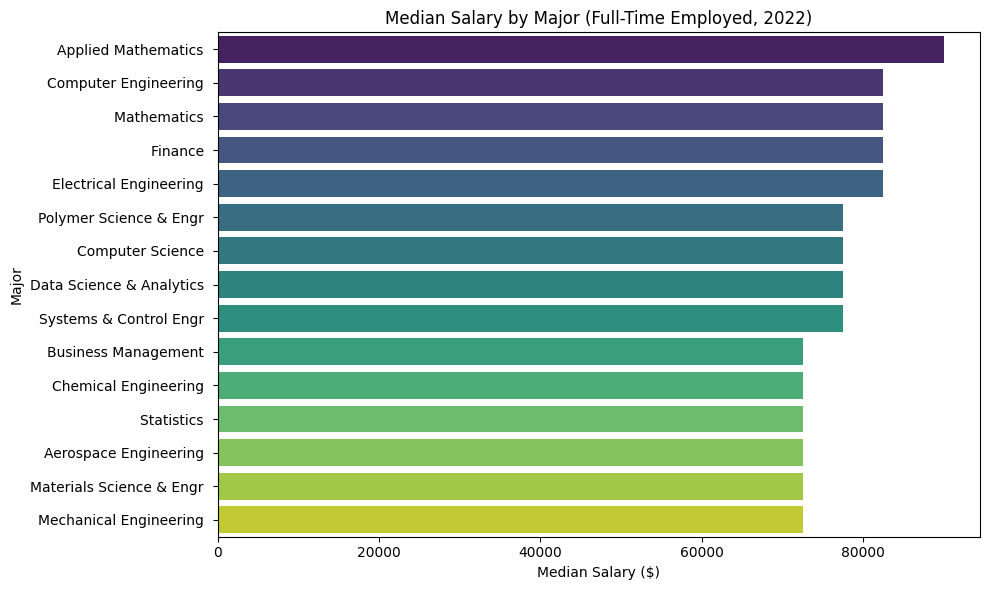

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\3031392914.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




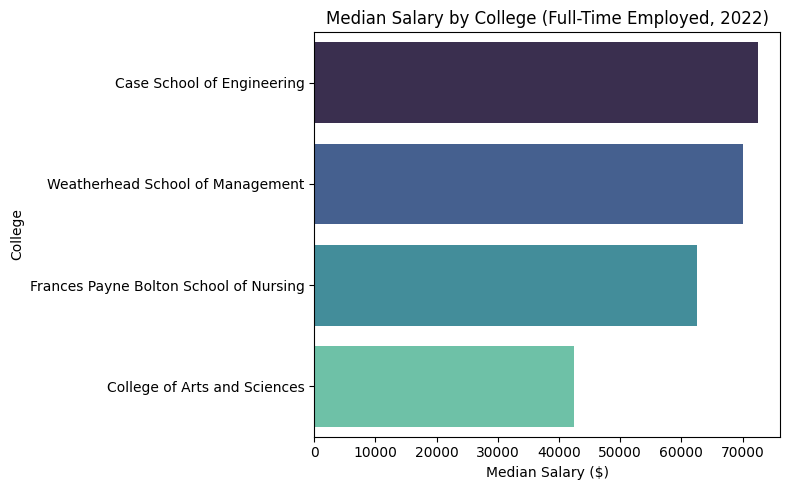

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\3031392914.py:64: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




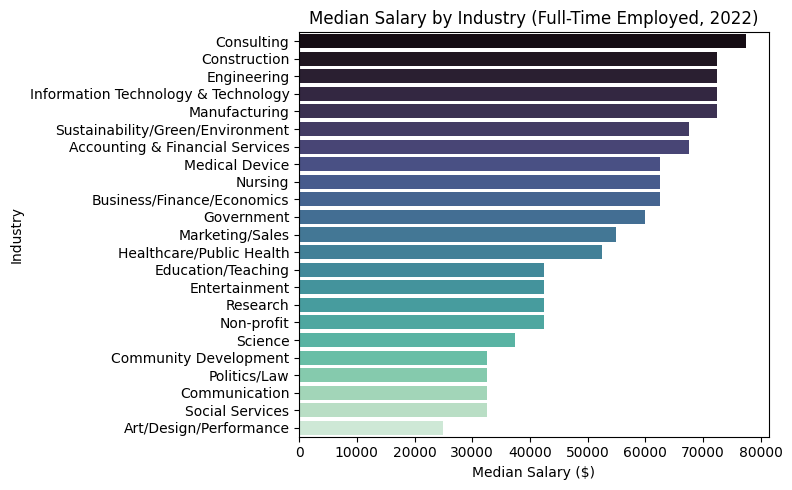


--- Median and Middle 50% Salary Range by Major (2022) ---


,Major,N (Students),Median,Q1,Q3,IQR
3,Applied Mathematics,2,"$90,000","$86,250","$93,750","$7,500"
17,Computer Engineering,3,"$82,500","$77,500","$82,500","$5,000"
34,Mathematics,3,"$82,500","$62,500","$87,500","$25,000"
26,Finance,7,"$82,500","$72,500","$82,500","$10,000"
22,Electrical Engineering,11,"$82,500","$70,000","$82,500","$12,500"
48,Polymer Science & Engr,1,"$77,500","$77,500","$77,500",$0
18,Computer Science,30,"$77,500","$72,500","$82,500","$10,000"
19,Data Science & Analytics,2,"$77,500","$75,000","$80,000","$5,000"
55,Systems & Control Engr,2,"$77,500","$75,000","$80,000","$5,000"
10,Business Management,9,"$72,500","$62,500","$72,500","$10,000"



--- Median and Middle 50% Salary Range by College (2022) ---


,College,N (Students),Median,Q1,Q3,IQR
0,Case School of Engineering,160,"$72,500","$67,500","$82,500","$15,000"
3,Weatherhead School of Management,40,"$70,000","$57,500","$77,500","$20,000"
2,Frances Payne Bolton School of Nursing,38,"$62,500","$57,500","$67,500","$10,000"
1,College of Arts and Sciences,167,"$42,500","$32,500","$62,500","$30,000"



--- Median and Middle 50% Salary Range by Industry (2022) ---


,JobField,N (Students),Median,Q1,Q3,IQR
6,Consulting,36,"$77,500","$62,500","$82,500","$20,000"
5,Construction,2,"$72,500","$72,500","$72,500",$0
8,Engineering,112,"$72,500","$67,500","$82,500","$15,000"
12,Information Technology & Technology,31,"$72,500","$70,000","$82,500","$12,500"
13,Manufacturing,3,"$72,500","$72,500","$77,500","$5,000"
22,Sustainability/Green/Environment,2,"$67,500","$67,500","$67,500",$0
0,Accounting & Financial Services,5,"$67,500","$57,500","$67,500","$10,000"
15,Medical Device,2,"$62,500","$60,000","$65,000","$5,000"
17,Nursing,27,"$62,500","$57,500","$67,500","$10,000"
2,Business/Finance/Economics,33,"$62,500","$52,500","$72,500","$20,000"


In [94]:
# Load data
df = pd.read_excel('FDS 2016-2024 for students.xlsx')
df.head()

# Filter for 2022 valid salary data
df = df[(df['Year'] == 2022) & (df['PlanFinal'] == 'Employed Full Time')].copy()

# Format salaries
def convert_salary_range(s):
    if pd.isna(s):
        return np.nan
    s = s.strip().replace('$','').replace(',','')

    # Handle "Less than" or "greater"
    if s.lower().startswith('less than'):
        num = ''.join([c for c in s if c.isdigit()])
        return float(num)
    if 'or greater' in s.lower():
        num = ''.join([c for c in s if c.isdigit()])
        return float(num)

    # Handle regular ranges like "80000-84999"
    try:
        low, high = s.split('-')
        low, high = int(low), int(high)
        return (low + high) / 2
    except:
        # Handle cases like single value "75000"
        try:
            return float(s)
        except:
            return np.nan

df['SalaryMidpoint'] = df['EmploymentSalary'].apply(convert_salary_range)

# Median by college and major and industry
median_by_major = df.groupby('Major')['SalaryMidpoint'].median().reset_index()
median_by_college = df.groupby('College')['SalaryMidpoint'].median().reset_index()
median_by_industry = df.groupby('JobField')['SalaryMidpoint'].median().reset_index()

# Median by major (top 15)
median_by_major = median_by_major.sort_values('SalaryMidpoint', ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(data=median_by_major, x='SalaryMidpoint', y='Major', palette='viridis')
plt.title('Median Salary by Major (Full-Time Employed, 2022)')
plt.xlabel('Median Salary ($)')
plt.ylabel('Major')
plt.tight_layout()
plt.show()

# Median by college
median_by_college = median_by_college.sort_values('SalaryMidpoint', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=median_by_college, x='SalaryMidpoint', y='College', palette='mako')
plt.title('Median Salary by College (Full-Time Employed, 2022)')
plt.xlabel('Median Salary ($)')
plt.ylabel('College')
plt.tight_layout()
plt.show()

# Median by industry
median_by_industry = median_by_industry.sort_values('SalaryMidpoint', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=median_by_industry, x='SalaryMidpoint', y='JobField', palette='mako')
plt.title('Median Salary by Industry (Full-Time Employed, 2022)')
plt.xlabel('Median Salary ($)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

# Statistics
def median_iqr_summary(df, group_col):
    summary = (
        df.groupby(group_col)['SalaryMidpoint']
        .agg(
            Count='count',
            Median='median',
            Q1=lambda x: x.quantile(0.25),
            Q3=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )
    summary['IQR'] = summary['Q3'] - summary['Q1']
    return summary

major_summary = median_iqr_summary(df, 'Major')
college_summary = median_iqr_summary(df, 'College')
industry_summary = median_iqr_summary(df, 'JobField')

pd.options.display.float_format = '${:,.0f}'.format

print("\n--- Median and Middle 50% Salary Range by Major (2022) ---")
display(major_summary.sort_values('Median', ascending=False).head(15).rename(columns={'Count': 'N (Students)'}))

print("\n--- Median and Middle 50% Salary Range by College (2022) ---")
display(college_summary.sort_values('Median', ascending=False).rename(columns={'Count': 'N (Students)'}))

print("\n--- Median and Middle 50% Salary Range by Industry (2022) ---")
display(industry_summary.sort_values('Median', ascending=False).rename(columns={'Count': 'N (Students)'}))



# Primary Plan

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\2417937376.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




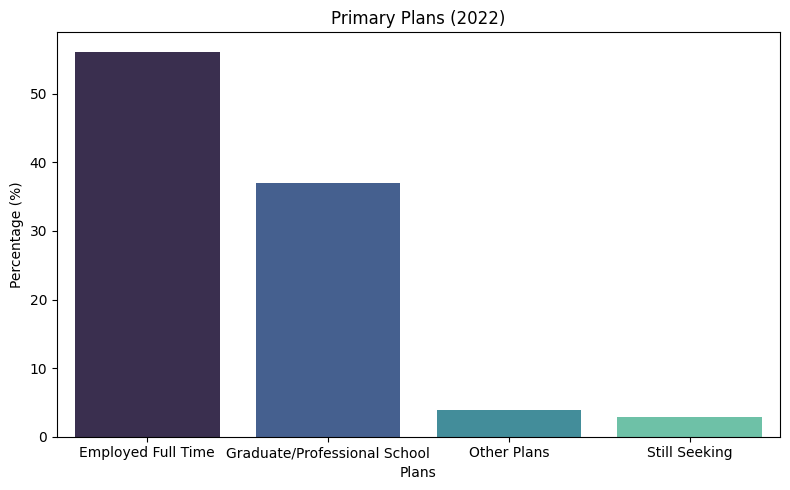

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\2417937376.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




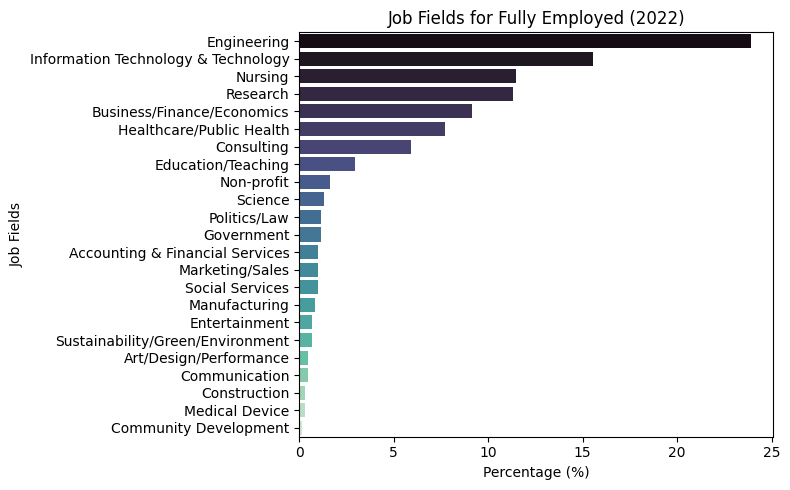

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\2417937376.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




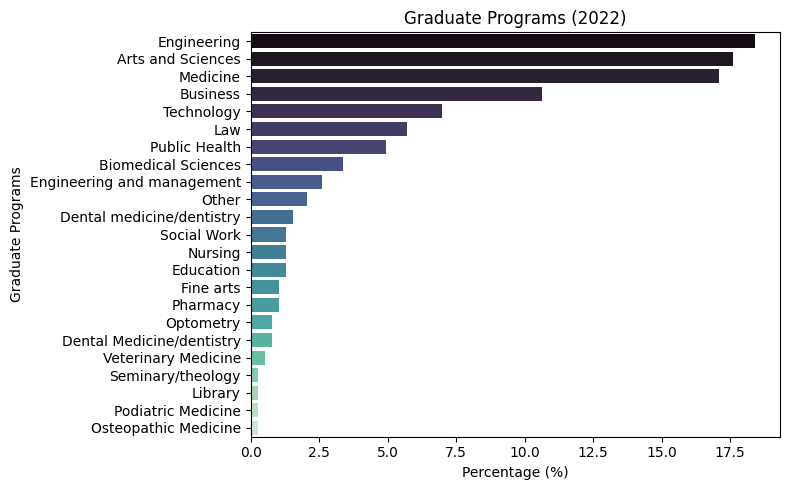

In [95]:
# Load data
df = pd.read_excel('FDS 2016-2024 for students.xlsx')
df.head()

# Filter for 2022 valid data
df = df[(df['Year'] == 2022) & (df['PlanFinal'] != 'Unknown')].copy()

# filter to important columns
filtered_df = df[['ID', 'PlanFinal', 'Employer', 'JobField', 'Institution', 'GraduateProgramArea', 'GraduateProgram', 'GraduateDegree']].drop_duplicates().reset_index(drop = True)

# filter for full time employment
employed_df = filtered_df[(filtered_df['PlanFinal'] == 'Employed Full Time')].drop(['Institution', 'GraduateProgramArea', 'GraduateProgram', 'GraduateDegree'], axis=1)

# filter for graduate/professional program
graduate_df = filtered_df[(filtered_df['PlanFinal'] == 'Graduate/Professional School')].drop(['Employer', 'JobField'], axis=1)

# find percentage for general plans
plan_counts = filtered_df['PlanFinal'].value_counts(normalize=True)*100
plan_data = plan_counts.reset_index()
plan_data.columns = ['Plan', 'Percentage']

# find percentages for job field (if employed)
job_field_data = employed_df['JobField'].value_counts(normalize=True)*100
job_field_data = job_field_data.reset_index()
job_field_data.columns = ['Job Field', 'Percentage']

# find percentages for grad program (if going to graduate school)
grad_data = graduate_df['GraduateProgramArea'].value_counts(normalize=True)*100
grad_data = grad_data.reset_index()
grad_data.columns = ['Graduate Program', 'Percentage']

# plot showing students plans post graduation
plt.figure(figsize=(8,5))
sns.barplot(plan_data, x='Plan', y='Percentage', palette='mako')
plt.title('Primary Plans (2022)')
plt.xlabel('Plans')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

# plot showing break down of job fields for students employed
plt.figure(figsize=(8,5))
sns.barplot(job_field_data, x='Percentage', y='Job Field', palette='mako')
plt.title('Job Fields for Fully Employed (2022)')
plt.xlabel('Percentage (%)')
plt.ylabel('Job Fields')
plt.tight_layout()
plt.show()

# plot showing break down of graduate programs for students attending grad school
plt.figure(figsize=(8,5))
sns.barplot(grad_data, x='Percentage', y='Graduate Program', palette='mako')
plt.title('Graduate Programs (2022)')
plt.xlabel('Percentage (%)')
plt.ylabel('Graduate Programs')
plt.tight_layout()
plt.show()







In [96]:
# load data
df = pd.read_excel('FDS 2016-2024 for students.xlsx')
df.head()

# Filter for 2022 valid data
df = df[(df['Year'] == 2022) & (df['PlanFinal'] != 'Unknown')].copy()


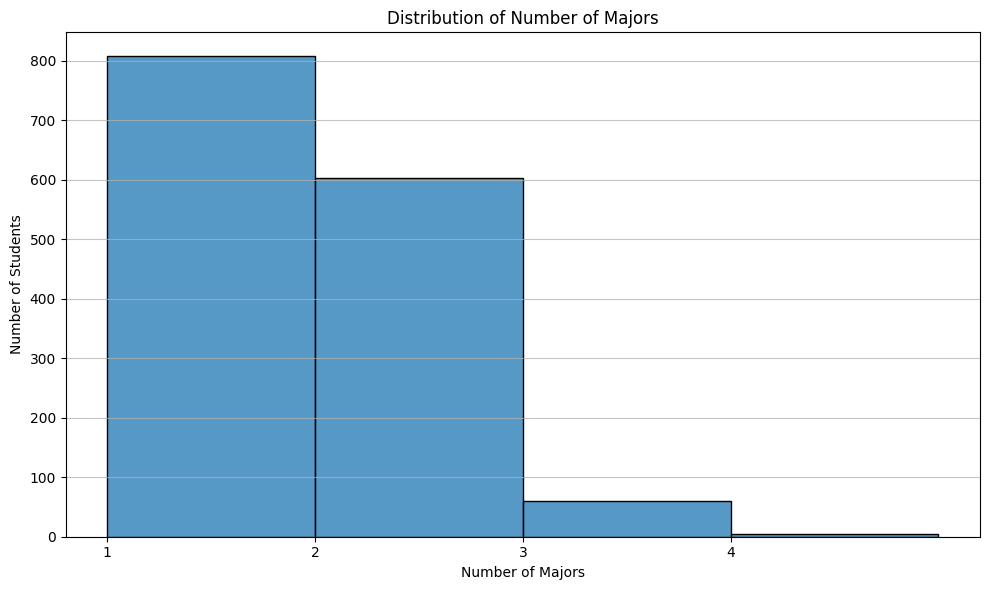

In [97]:
if 'NumberofMajors' not in df.columns:
    print("Error: 'NumberOfMajors' column not found in the DataFrame.")
    print("Available columns are:", df.columns.tolist())
    print("Please provide the correct column name or instructions on how to create it.")
else:

    plt.figure(figsize=(10, 6))
    sns.histplot(df['NumberofMajors'], bins=range(1, int(df['NumberofMajors'].max()) + 2), kde=False, stat='count')
    plt.title('Distribution of Number of Majors')
    plt.xlabel('Number of Majors')
    plt.ylabel('Number of Students')
    plt.xticks(range(1, int(df['NumberofMajors'].max()) + 1))
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

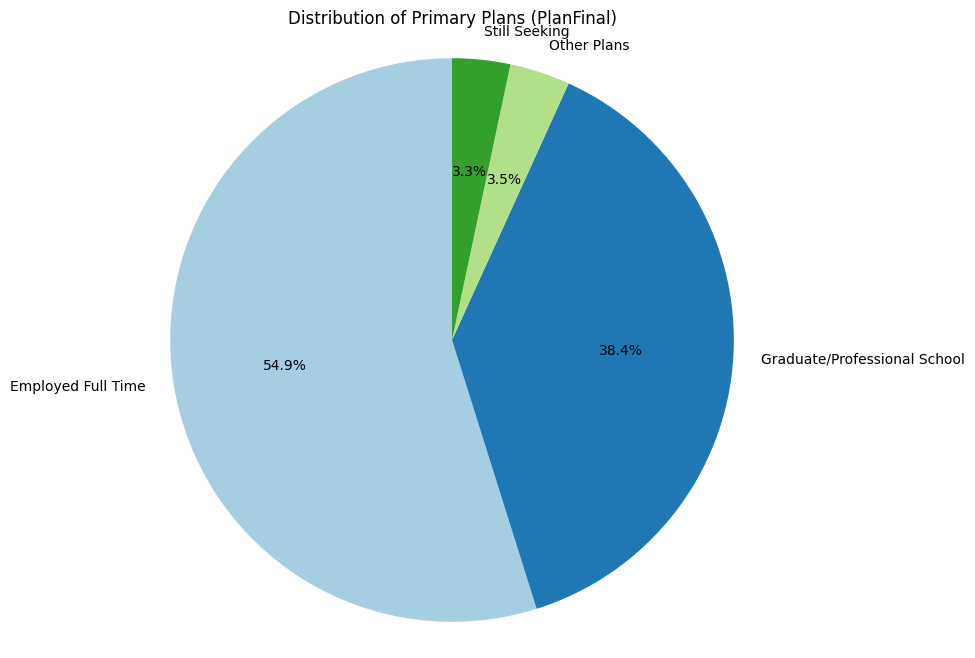

In [98]:

plan_final_counts = df['PlanFinal'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(plan_final_counts, labels=plan_final_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Primary Plans (PlanFinal)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

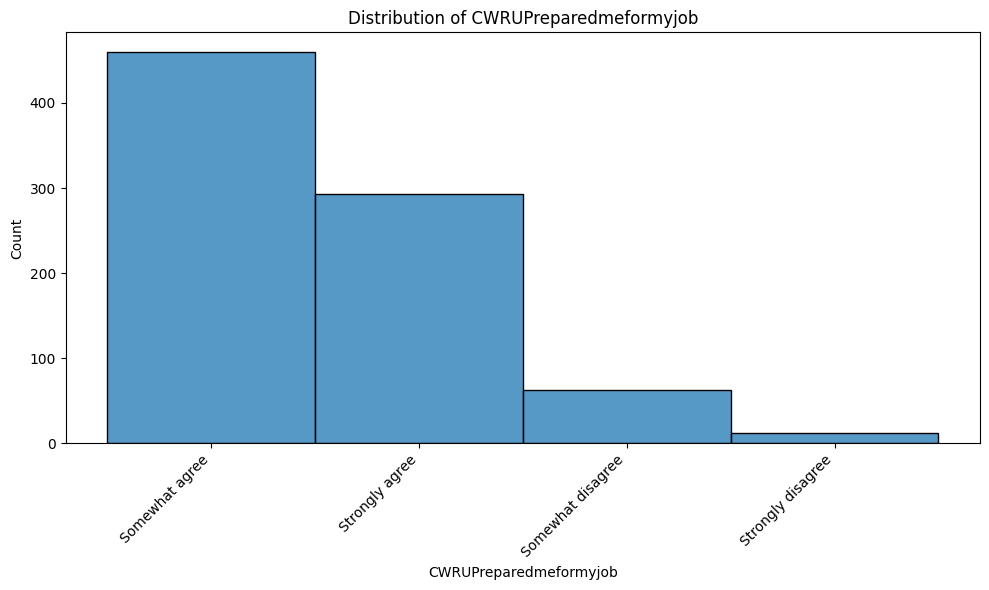

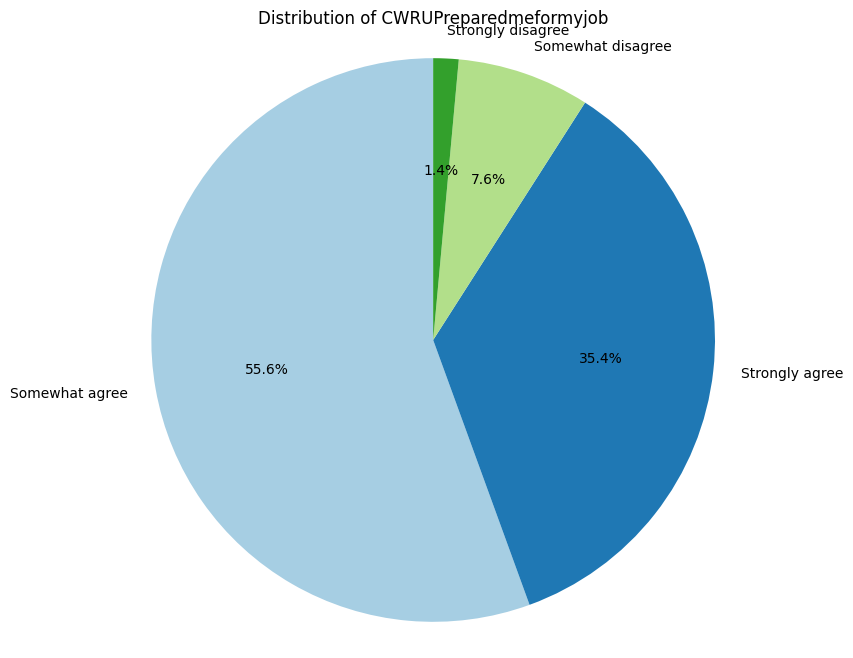

In [99]:

column_name = 'CWRUPreparedmeformyjob'

if column_name not in df.columns:
    print(f"Error: '{column_name}' column not found in the DataFrame.")
    print("Available columns are:", df.columns.tolist())
    print("Please provide the correct column name or instructions on how to create it.")
else:
    # Histogram (or count plot if categorical)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=column_name, discrete=True)
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Pie Chart
    plan_counts = df[column_name].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(plan_counts, labels=plan_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Distribution of {column_name}')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

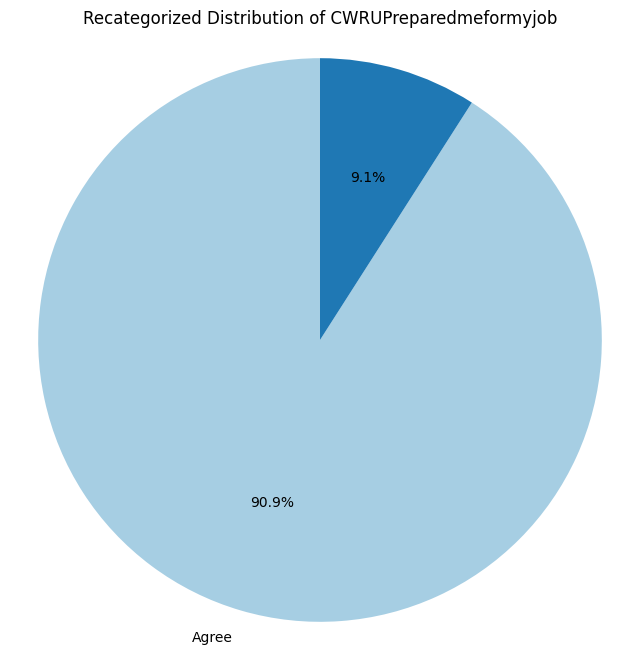

In [100]:


column_name = 'CWRUPreparedmeformyjob'

if column_name not in df.columns:
    print(f"Error: '{column_name}' column not found in the DataFrame.")
    print("Available columns are:", df.columns.tolist())
else:
    recategorized_responses = df[column_name].copy()

    recategorized_responses[recategorized_responses.isin(['Strongly agree', 'Somewhat agree'])] = 'Agree'

    #make disagree answers less obvious by not adding a label/blank label
    recategorized_responses[recategorized_responses.isin(['Somewhat disagree', 'Strongly disagree'])] = ' '

    plan_counts_recategorized = recategorized_responses.value_counts().dropna()
    plt.figure(figsize=(8, 8))
    plt.pie(plan_counts_recategorized, labels=plan_counts_recategorized.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Recategorized Distribution of {column_name}')
    plt.axis('equal')
    plt.show()

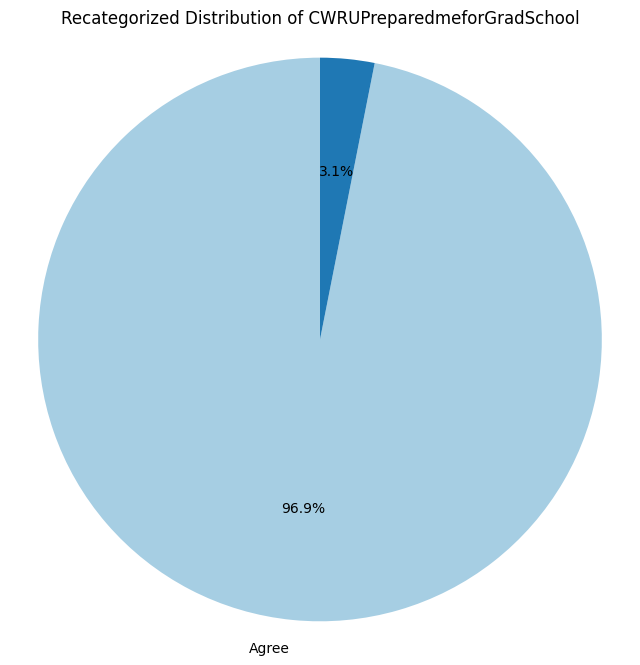

In [101]:
column_name = 'CWRUPreparedmeforGradSchool'

if column_name not in df.columns:
    print(f"Error: '{column_name}' column not found in the DataFrame.")
    print("Available columns are:", df.columns.tolist())
else:
    recategorized_responses = df[column_name].copy()

    # 'Strongly agree' + 'Somewhat agree' = 'Agree'
    recategorized_responses[recategorized_responses.isin(['Strongly agree', 'Somewhat agree'])] = 'Agree'

    # 'Somewhat disagree' + 'Strongly disagree' = 'Disagree'
    #make disagree answers less obvious by not adding a label/blank label
    recategorized_responses[recategorized_responses.isin(['Somewhat disagree', 'Strongly disagree'])] = ' '

    # calculate and drop NaN
    plan_counts_recategorized = recategorized_responses.value_counts().dropna()

    plt.figure(figsize=(8, 8))
    plt.pie(plan_counts_recategorized, labels=plan_counts_recategorized.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Recategorized Distribution of {column_name}')
    plt.axis('equal')
    plt.show()

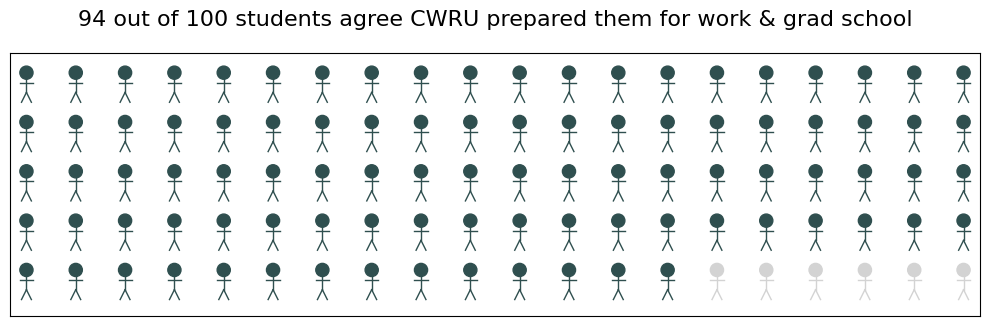

In [102]:
def draw_stick_figure(ax, x, y, scale_factor=1.0, color='black'):

    head_radius = 0.2 * scale_factor
    head_center_y = y + (0.9 * scale_factor)
    head = plt.Circle((x, head_center_y), head_radius, color=color)
    ax.add_patch(head)

    body_start_y = y + (0.3 * scale_factor)
    body_end_y = y + (0.7 * scale_factor)
    ax.plot([x, x], [body_start_y, body_end_y], color=color, linewidth=2 * scale_factor)

    arm_spread = 0.2 * scale_factor
    arm_height = y + (0.6 * scale_factor)
    ax.plot([x - arm_spread, x + arm_spread], [arm_height, arm_height], color=color, linewidth=2 * scale_factor)

    leg_spread = 0.15 * scale_factor
    leg_start_y = y + (0.3 * scale_factor)
    ax.plot([x, x - leg_spread], [leg_start_y, y], color=color, linewidth=2 * scale_factor)
    ax.plot([x, x + leg_spread], [leg_start_y, y], color=color, linewidth=2 * scale_factor)

# number figures
num_figures = 100
#0.91
num_dark = 94

fig, ax = plt.subplots(figsize=(10, 10))
cols = 20
rows = 5

#scale the size of the stick people
drawing_scale = 0.5

for i in range(num_figures):
    row = i // cols
    col = i % cols

    x_pos = col * (1.5 * drawing_scale)
    y_pos = -row * (1.5 * drawing_scale)

    if i < num_dark:
        draw_stick_figure(ax, x_pos, y_pos, scale_factor=drawing_scale, color='darkslategrey')
    else:
        draw_stick_figure(ax, x_pos, y_pos, scale_factor=drawing_scale, color='lightgrey')


ax.set_xlim(-0.5 * drawing_scale, ((cols - 1) * 1.5 + 0.5) * drawing_scale)
ax.set_ylim((-(rows - 1) * 1.5 - 0.5) * drawing_scale, 1.5 * drawing_scale)

ax.set_aspect('equal')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.title('94 out of 100 students agree CWRU prepared them for work & grad school', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

In [103]:
# Get most common employers
print("\n--- Most Common Employers (Full-Time Employed) ---")
print(employed_df['Employer'].value_counts().head(30))

# Get most common graduate institutions
print("\n--- Most Common Graduate/Professional Institutions ---")
print(graduate_df['Institution'].value_counts().head(30))


--- Most Common Employers (Full-Time Employed) ---
Employer
Cleveland Clinic                   40
Epic                               26
University Hospitals               15
Deloitte                           14
Case Western Reserve University    11
Amazon                              8
Microsoft                           7
Rockwell Automation                 6
General Motors                      5
General Electric                    5
P&G                                 5
Boeing Company                      5
Empl.OtherOrig                      4
Sherwin-Williams                    4
Pfizer                              4
Google                              4
KeyBank                             4
Lubrizol                            4
MedStar Health                      4
National Institutes of Health       4
Johns Hopkins Hospital              4
EY                                  4
JPMorgan Chase                      4
Publicis Sapient                    4
Nationwide Children's Hospi

# Graph by States

In [104]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

df['State_Abbrev'] = df['EmploymentState'].map(state_abbrev)

df_state_counts = df.groupby('State_Abbrev').size().reset_index(name='Count')


In [105]:
my_colors = ['#6baed6','#08306b',"#1a3f62","#0b1d2e"]

In [106]:
fig = px.choropleth(
    df_state_counts,
    locations='State_Abbrev',
    locationmode='USA-states',
    color='Count',
    color_continuous_scale=my_colors,
    scope='usa',
    title='Where Graduates Work (2022)'
)

fig.show()

In [107]:
fig = px.choropleth(
    df_state_counts,
    locations='State_Abbrev',
    locationmode='USA-states',
    color='Count',
    color_continuous_scale=my_colors,
    scope='usa',
    title='Where Graduates Work (2022)'
)

state_centers = {
    'AL': (-86.8, 32.8), 'AK': (-152.4, 64.2), 'AZ': (-111.7, 34.2),
    'AR': (-92.3, 34.8), 'CA': (-119.5, 37.3), 'CO': (-105.6, 39.0),
    'CT': (-72.7, 41.6), 'DE': (-75.5, 39.0), 'FL': (-82.4, 28.4),
    'GA': (-83.5, 32.7), 'HI': (-155.5, 19.9), 'ID': (-114.0, 45.6),
    'IL': (-89.2, 40.0), 'IN': (-86.0, 40.3), 'IA': (-93.5, 42.1),
    'KS': (-98.0, 38.5), 'KY': (-85.3, 37.7), 'LA': (-91.9, 30.9),
    'ME': (-69.0, 45.3), 'MD': (-76.7, 39.0), 'MA': (-71.8, 42.3),
    'MI': (-84.6, 44.3), 'MN': (-94.2, 46.3), 'MS': (-89.7, 32.7),
    'MO': (-92.6, 38.5), 'MT': (-110.0, 46.9), 'NE': (-99.8, 41.5),
    'NV': (-116.7, 39.4), 'NH': (-71.5, 43.2), 'NJ': (-74.5, 40.1),
    'NM': (-106.1, 34.4), 'NY': (-75.5, 42.9), 'NC': (-79.0, 35.6),
    'ND': (-100.4, 47.5), 'OH': (-82.8, 40.3), 'OK': (-97.3, 35.6),
    'OR': (-120.6, 44.1), 'PA': (-77.6, 41.2), 'RI': (-71.5, 41.7),
    'SC': (-80.9, 33.9), 'SD': (-100.3, 44.4), 'TN': (-86.7, 35.7),
    'TX': (-99.3, 31.5), 'UT': (-111.7, 40.2), 'VT': (-72.7, 44.0),
    'VA': (-78.5, 37.5), 'WA': (-120.5, 47.3), 'WV': (-80.6, 38.6),
    'WI': (-89.6, 44.6), 'WY': (-107.3, 43.0), 'DC': (-77.01, 38.91)
}


counts = df_state_counts['Count']
norm = (counts - counts.min()) / (counts.max() - counts.min() + 1e-9)

viridis = cm.get_cmap('viridis_r')

df_state_counts['rgb'] = norm.apply(lambda x: viridis(x))

for _, row in df_state_counts.iterrows():
    state = row['State_Abbrev']
    count = row['Count']
    r, g, b, _ = row['rgb']  # alpha ignored

    # perceived luminance (human brightness)
    luminance = (0.299*r + 0.587*g + 0.114*b)

    # choose black text on bright colors, white on dark colors
    text_color = "black" if luminance > 0.5 else "white"

    if state in state_centers:
        lon, lat = state_centers[state]
        fig.add_trace(go.Scattergeo(
            lon=[lon],
            lat=[lat],
            text=str(count),
            mode='text',
            showlegend=False,
            textfont=dict(color=text_color, size=11, family="Times New Roman")
        ))

fig.show()


C:\Users\bhoom\AppData\Local\Temp\ipykernel_31136\4039553560.py:35: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



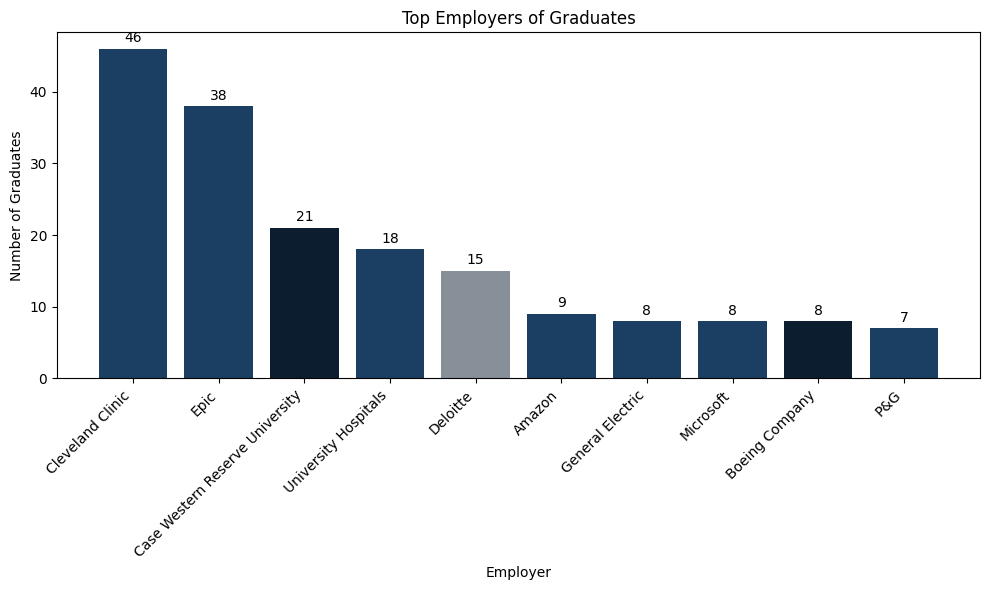

In [110]:

top_employers = df['Employer'].value_counts().head(10)
colors = [
    "#1a3f62", # cwru blue
    "#1a3f62",
    "#0b1d2e",
    "#1a3f62",
    "#879099",
    "#1a3f62",
]

plt.figure(figsize=(10, 6))
bars = plt.bar(top_employers.index, top_employers.values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             str(int(height)), ha='center', va='bottom')

plt.ylabel('Number of Graduates')
plt.xlabel('Employer')
plt.title('Top Employers of Graduates')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

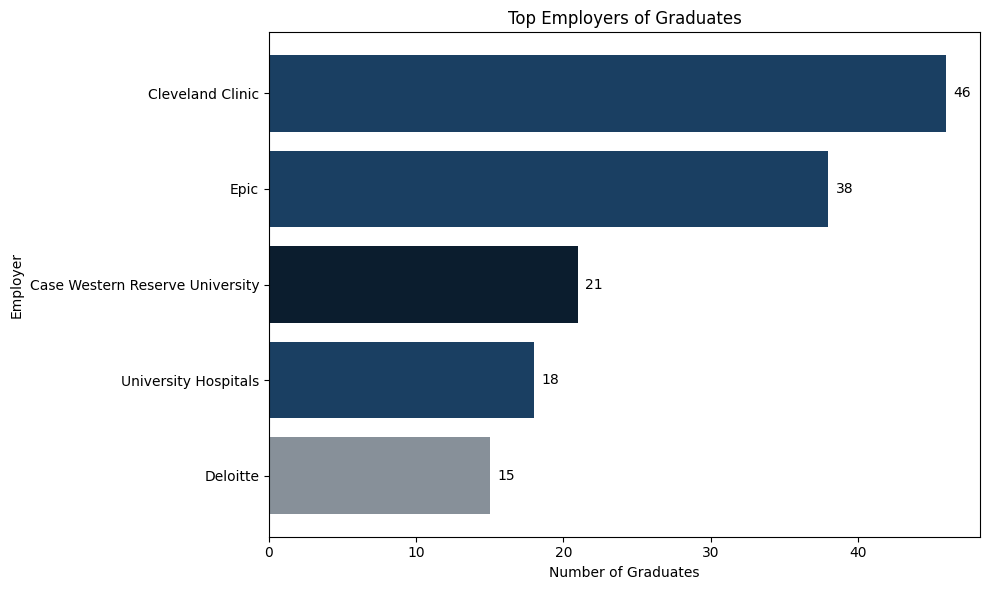

In [109]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top_employers.index, top_employers.values, color=colors)

# Add text labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(width)), va='center')

plt.xlabel('Number of Graduates')
plt.ylabel('Employer')
plt.title('Top Employers of Graduates')
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()